In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

In [4]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], df_sdt["flux_error_mJy"])
print(x0/1e14)

Optimal Pivot: 5.90e+14
5.903434426266961


In [5]:
host_galaxy_extinction_curve(df_sdt["frequency_Hz"], z=0.572)

array([1.36808287, 1.07807269, 0.87557649, 1.72843137, 1.55197314,
       1.44724872, 1.36808287, 1.2968336 , 1.23236998, 1.18058997,
       1.14344603, 1.10939742, 1.07807269, 1.04746213, 1.01882637,
       0.98677249, 0.90522876, 0.86840256, 0.833878  , 0.80144583,
       0.77092144, 0.74341737])

## 7DT SED fit

In [ ]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)

eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=1e15) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_error_mJy"], x_data_error=df_sdt["frequency_Hz_error"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1644..-52.1643]*| it/evals=4145/107629 eff=3.8620% N=300   0  00   0 0 
[ultranest] Likelihood function evaluations: 107665
[ultranest]   logZ = -61.4 +- 0.1357
[ultranest] Effective samples strategy satisfied (ESS = 1202.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.


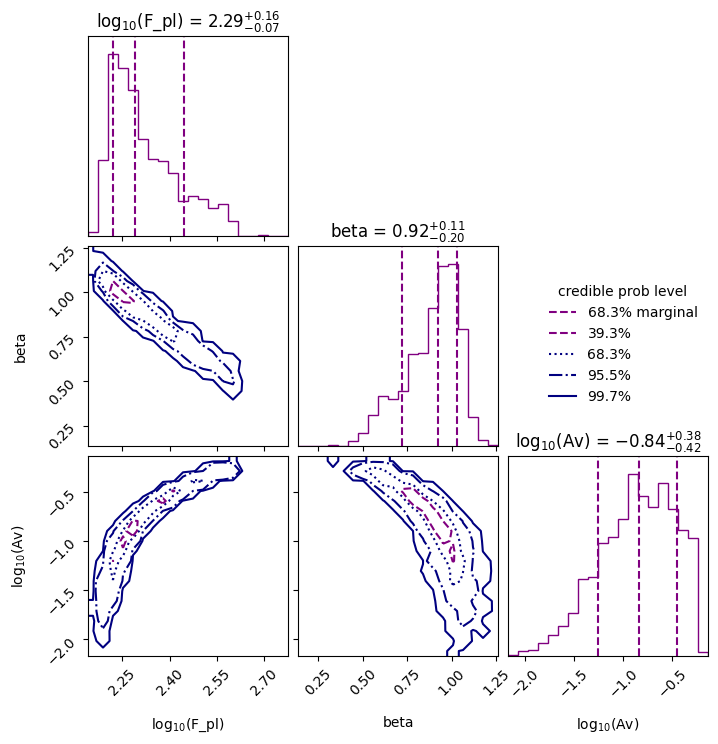

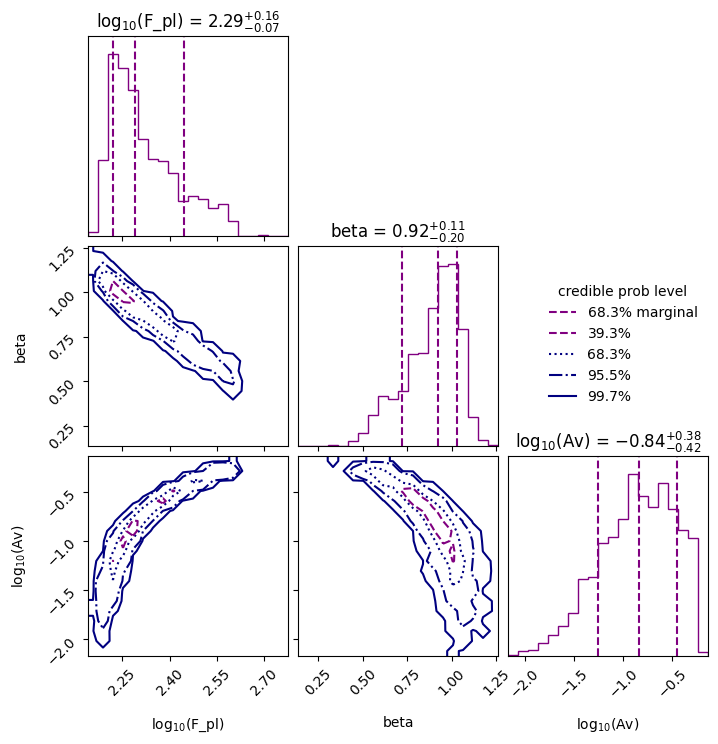

In [4]:
alz_sed.plot_corner()

<Axes: xlabel='Frequency', ylabel='Flux'>

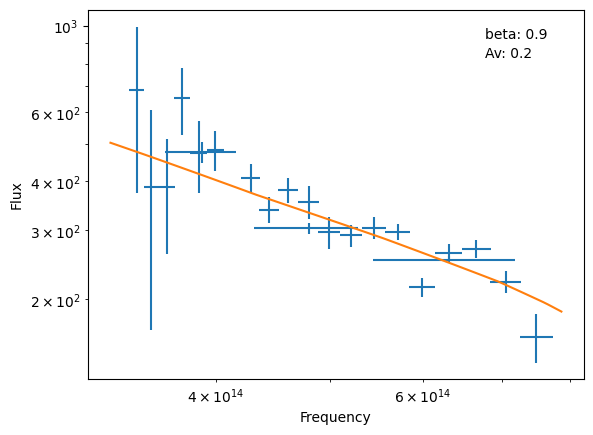

In [5]:
alz_sed.plot_data()
alz_sed.plot_model(show_param=True)


## XRT fit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *

In [2]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
alz_xrt = Analyzer(df_filtered["Time"][5:]/3600, df_filtered["Flux"][5:], broken_power_law, y_data_error=y_err[5:])
alz_xrt.run(method="curve_fit")

In [83]:
df = read_data("circular", add_converted_flux=True)

In [84]:
df["Facility"].value_counts()

Facility
Leavitt                               53
Calapai                               40
BassanoBrescianoObservatory           40
MASTER-SAAO                           27
7DT                                   22
NUTTelA-TAO                            8
OsservatorioAstronomicoNastroVerde     8
Mondy/AZT-33IK                         8
BOOTES-6/DPRT                          7
ISON-Castelgrande                      7
SAO/Zeiss-1000                         6
INO340                                 6
SAORAS                                 5
LCO                                    5
LiverpoolTelescope                     5
OHP/T193                               4
SVOM/COLIBRÍ                           3
Kilonova-Catcher                       3
SVOM/VT                                2
SYSU                                   2
LAST                                   2
Swift/UVOT                             2
Asiago                                 2
Koshka/Ziess-1000                      2
ABObser

In [3]:
#filter_name = "Rc"
facility_name = "BassanoBrescianoObservatory"

df = read_data("circular", add_converted_flux=True, correct_galactic_extinction=True)
df = filter_data(df,  facility_name=facility_name, remove_upper_limits=True)


In [7]:
df = read_data("i_data", add_converted_flux=True, correct_galactic_extinction=True)

In [8]:
df

,time,magnitude,mag_error,filter,wavelength,filter_width,gal_extinction,gal_corrected,frequency_Hz,frequency_Hz_error,flux_mJy,flux_mJy_error
0,94.029878,13.291055,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,17.522828,1.613912
1,96.890684,13.368897,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,16.310510,1.502254
2,108.804065,13.571678,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,13.531783,1.246323
3,117.959318,13.767801,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,11.295512,1.040355
4,121.804526,13.854738,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,10.426316,0.960299
...,...,...,...,...,...,...,...,...,...,...,...,...
62,7980.612064,15.820845,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,1.704859,0.157023
63,8192.214215,15.838665,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,1.677105,0.154467
64,8408.126108,15.820912,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,1.704753,0.157014
65,8923.873776,16.010712,0.1,i,7625.0,1103.0,0.098234,True,3.931704e+14,3.065434e+13,1.431336,0.131831


<Axes: xlabel='Time', ylabel='Flux'>

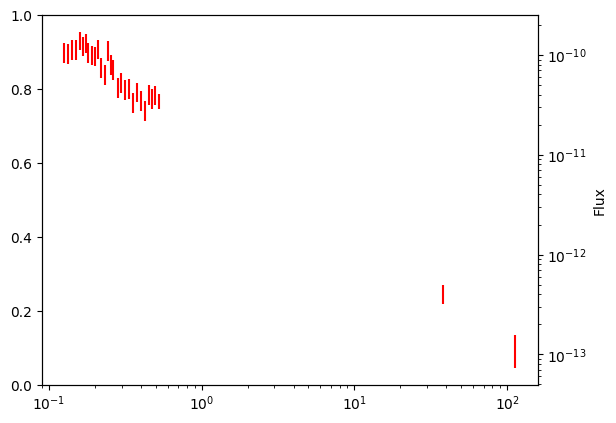

In [4]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["flux_high"], df_filtered["flux_low"])])
ax = plt.gca()
ax2 = ax.twinx()
alz_xrt = Analyzer(df_filtered["time"]/3600, df_filtered["flux"], power_law, y_data_error=y_err)
alz_xrt.plot_data(ax=ax2, color="red")


[1.58550151e-11 1.03197619e+00]


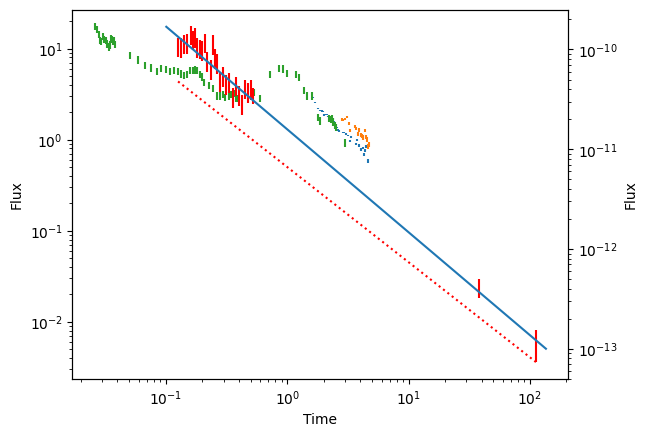

In [5]:
df = read_data("circular", add_converted_flux=True, correct_galactic_extinction=True)

df_Rc = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

alz_Rc = Analyzer(df_Rc["time"]/3600, df_Rc["flux_mJy"], power_law, y_data_error=df_Rc["flux_mJy_error"])
alz_Rc.plot_data()


df_Ic = filter_data(df, filter_name=["Ic"], remove_upper_limits=True, facility_name= "Leavitt")

alz_Ic = Analyzer(df_Ic["time"]/3600, df_Ic["flux_mJy"], power_law, y_data_error=df_Ic["flux_mJy_error"])
alz_Ic.plot_data()

df_i = read_data("i_data", add_converted_flux=True, correct_galactic_extinction=True)
alz_i = Analyzer(df_i["time"]/3600, df_i["flux_mJy"], power_law, y_data_error=df_i["flux_mJy_error"])
alz_i.plot_data()


df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["flux_high"], df_filtered["flux_low"])])
ax = plt.gca()
ax2 = ax.twinx()
alz_xrt = Analyzer(df_filtered["time"]/3600, df_filtered["flux"], power_law, y_data_error=y_err)
alz_xrt.plot_data(ax=ax2, color="red")
alz_xrt.run(method="curve_fit")
alz_xrt.plot_model()
print(alz_xrt.best_fit_params)
from grb.lightcurve import extrapolate_xrt_flux_density
df_xrt_i = extrapolate_xrt_flux_density(
    7625,
    use_mean_index=True,
    fit_flux_power_law=True,
)
ax.plot(df_xrt_i["time"]/3600, df_xrt_i["flux_density"], color="red", ls=":")

[8.21574783 2.55675642]


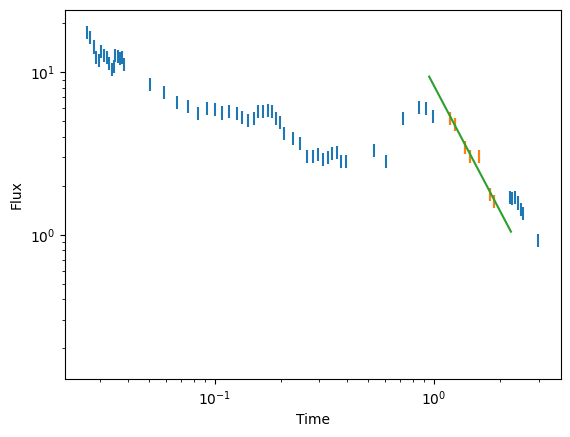

In [7]:
df_i = read_data("i_data", add_converted_flux=True, correct_galactic_extinction=True)
alz_i = Analyzer(df_i["time"]/3600, df_i["flux_mJy"], power_law, y_data_error=df_i["flux_mJy_error"])
alz_i.plot_data()

df_i = read_data("i_data", add_converted_flux=True, correct_galactic_extinction=True)
t_range = [53, 60]
df_selected = df_i.iloc[t_range[0]:t_range[1]]
alz_i = Analyzer(df_selected["time"]/3600, df_selected["flux_mJy"], power_law, y_data_error=df_selected["flux_mJy_error"])
alz_i.plot_data()
alz_i.run(method="curve_fit")
alz_i.plot_model()
print(alz_i.best_fit_params)

In [77]:
df_i["time"][:10]

0     94.029878
1     96.890684
2    100.574010
3    103.304585
4    106.054594
5    108.804065
6    111.704156
7    115.422295
8    117.959318
9    121.804526
Name: time, dtype: float64

In [78]:
df_Calapaia

NameError: name 'df_Calapaia' is not defined

In [ ]:
df_Ic

,date_obs,time,facility,magnitude,mag_error,filter,exposure,Circular,upper_limit,wavelength,filter_width,gal_extinction,gal_corrected,frequency_Hz,frequency_Hz_error,flux_mJy,flux_mJy_error
78,2025-10-13 20:28:19.200,10117.2,Leavitt,15.848928,0.03,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.661326,0.045904
90,2025-10-13 20:34:04.800,10462.8,Leavitt,15.858928,0.03,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.646095,0.045483
100,2025-10-13 20:39:50.400,10808.4,Leavitt,15.828928,0.03,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.692212,0.046758
109,2025-10-13 20:47:02.400,11240.4,Leavitt,15.768928,0.03,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.788360,0.049414
116,2025-10-13 20:52:48.000,11586.0,Leavitt,15.958928,0.04,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.501256,0.055308
123,2025-10-13 20:58:33.600,11931.6,Leavitt,16.158928,0.04,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.248691,0.046003
139,2025-10-13 21:17:16.800,13054.8,Leavitt,16.048928,0.04,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.381831,0.050909
146,2025-10-13 21:23:02.400,13400.4,Leavitt,16.098928,0.04,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.319638,0.048617
151,2025-10-13 21:30:14.400,13832.4,Leavitt,16.238928,0.05,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.159992,0.053420
155,2025-10-13 21:36:00.000,14178.0,Leavitt,16.138928,0.05,Ic,NaN,42333.0,False,7980.0,1540.0,0.091072,True,3.756798e+14,4.012114e+13,1.271906,0.058573


In [ ]:
df[df["facility"]=="Leavitt"]

,date_obs,time,facility,magnitude,mag_error,filter,exposure,Circular,upper_limit,wavelength,filter_width,frequency_Hz,frequency_Hz_error,flux_mJy,flux_mJy_error
25,2025-10-13 19:17:45.600,5883.6,Leavitt,15.38,0.01,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,2.558741,0.023567
27,2025-10-13 19:22:04.800,6142.8,Leavitt,15.51,0.01,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,2.270002,0.020907
28,2025-10-13 19:26:24.000,6402.0,Leavitt,15.67,0.01,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.958963,0.018043
32,2025-10-13 19:30:43.200,6661.2,Leavitt,15.73,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.853644,0.034145
33,2025-10-13 19:35:02.400,6920.4,Leavitt,15.74,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.836649,0.033832
34,2025-10-13 19:37:55.200,7093.2,Leavitt,15.76,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.803127,0.033215
39,2025-10-13 19:40:48.000,7266.0,Leavitt,15.86,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.644471,0.030292
41,2025-10-13 19:43:40.800,7438.8,Leavitt,15.84,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.675044,0.030855
43,2025-10-13 19:46:33.600,7611.6,Leavitt,15.84,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.675044,0.030855
47,2025-10-13 19:50:52.800,7870.8,Leavitt,15.89,0.02,Rc,NaN,42333.0,False,6410.0,1580.0,4.676949e+14,6.574360e+13,1.599655,0.029467


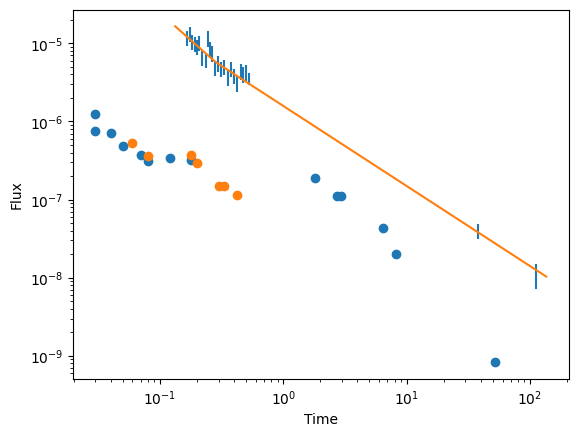

In [ ]:
alz_xrt.plot_data()
alz_xrt.plot_model()
plt.scatter(df["Time"], df["flux_mJy"]/1e7)
plt.scatter(alz_BBO.x_data, alz_BBO.y_data/1e7)

#plt.plot(df_xrt["Time"]/3600, df_xrt["Flux"])

In [ ]:
from grb.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

alz_Rc = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_Rc.run(method="curve_fit")

## Clear filters

In [ ]:
df = read_data("circular", add_converted_flux=True)
filtered_df = filter_data(df, remove_upper_limits=True, facility_name= "BOOTES-6/DPRT")
alz_BBO = Analyzer(filtered_df["Time"], filtered_df["flux_mJy"], power_law, y_data_error=filtered_df["flux_error_mJy"])
alz_BBO.run(method="curve_fit")

<Axes: xlabel='Time', ylabel='Flux'>

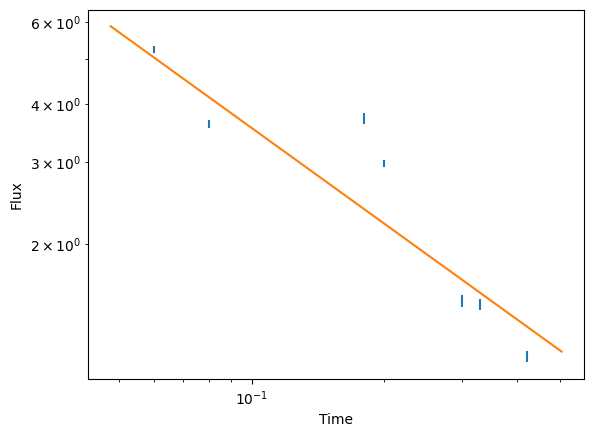

In [ ]:
alz_BBO.plot_data()
alz_BBO.plot_model()

In [ ]:
df = read_data("circular", add_converted_flux=True)
filtered_df = filter_data(df, remove_upper_limits=True, facility_name= "Calapai")
alz_calapai = Analyzer(filtered_df["Time"], filtered_df["flux_mJy"], broken_power_law, y_data_error=filtered_df["flux_error_mJy"])
alz_calapai.run(method="ultranest")
print(alz_calapai.best_fit_params)

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+02  .25 [-534.4413..-534.4411]*| it/evals=9330/436061 eff=2.1388% N=290    0   0   
[ultranest] Likelihood function evaluations: 436097
[ultranest]   logZ = -561.9 +- 0.1845
[ultranest] Effective samples strategy satisfied (ESS = 1698.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.30 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.
[0.31883678612492183, 5.16032318449346, 1.2753034173656008, 2.0703314407716524]


## Ic band fit

In [ ]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Ic"], remove_upper_limits=True, facility_name= "Leavitt")
alz_Ic = Analyzer(df["Time"], df["flux_mJy"], broken_power_law, y_data_error=df["flux_error_mJy"])
alz_Ic.run(method="curve_fit")

## i band fit

In [ ]:
filter_name = "i"

df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=filter_name, remove_upper_limits=True)

combined_func = lambda t, *params: power_law(t, *params[:2]) +  broken_power_law(t, *params[2:])

param_bounds, prior = power_law_prior()
param_bounds_bknpl, prior_bknpl = broken_power_law_prior()
param_bounds.update(param_bounds_bknpl)
prior.update(prior_bknpl)
# param_bounds["alpha_d"] = (alz_Ic.results["posterior"]["mean"][1], alz_Ic.results["posterior"]["stdev"][1])
# prior["alpha_d"] = "norm"

alz_i = Analyzer(df["Time"], df["flux_mJy"], combined_func, param_bounds=param_bounds, prior=prior, y_data_error=df["flux_error_mJy"])
alz_i.run(method="curve_fit")

## Rc band fit

In [ ]:
from grb.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

alz_Rc = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_Rc.run(method="curve_fit")

## r/ r' bands fit

In [ ]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4))

alz_r = Analyzer(df["Time"], df["flux_mJy"], broken_power_law, y_data_error=df["flux_error_mJy"])
alz_r.run(method="curve_fit")

## g band fit

In [ ]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["g"], remove_upper_limits=True, exclude_time_range=(20, 1e4))
alz_g = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_g.run(method="curve_fit")

In [ ]:
from grb.io import read_data
from datetime import datetime

times = read_data("sdt")["date_obs"]

sdt_min = (datetime.strptime(min(times), "%Y-%m-%dT%H:%M:%S.%f") -TRIGGER_TIME).total_seconds()/3600.
sdt_max = (datetime.strptime(max(times), "%Y-%m-%dT%H:%M:%S.%f")-TRIGGER_TIME).total_seconds()/3600.
sdt_ave = (sdt_min + sdt_max)/2

In [ ]:
alz_Ic.best_fit_params

array([ 0.16482339, 14.77391624,  1.16108773,  1.88708998])

In [ ]:
alz_calapai.best_fit_params

array([0.45785138, 3.91000321, 1.26203036, 1.50369645])

In [ ]:
from grb.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

st = 20
alz_Rc = Analyzer(df["Time"][st:], df["flux_mJy"][st:], power_law, y_data_error=df["flux_error_mJy"][st:])
alz_Rc.run(method="curve_fit")

In [ ]:
df = read_data("circular", add_converted_flux=True)
filtered_df = filter_data(df, remove_upper_limits=True, facility_name= "Calapai")
alz_calapai = Analyzer(filtered_df["Time"], filtered_df["flux_mJy"], broken_power_law, y_data_error=filtered_df["flux_error_mJy"])
alz_calapai.run(method="curve_fit")

array([3.23147025, 1.18539978])

[3.23147025 1.18539978]
[ 0.16482339 14.77391624  1.16108773  1.88708998]
[0.45785138 3.91000321 1.26203036 1.50369645]


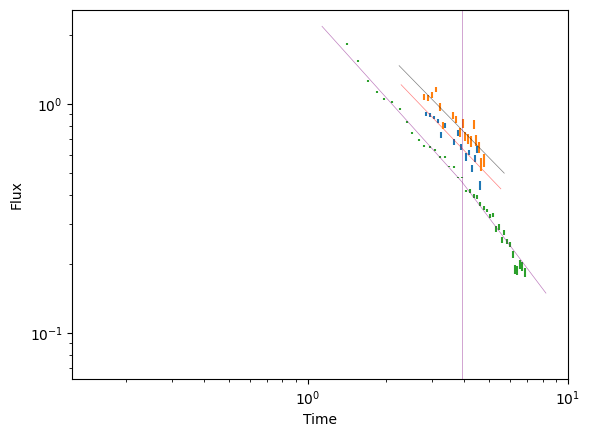

In [ ]:
alz_Rc.plot_data(label="Rc")
alz_Rc.plot_model(color="red", lw=0.5, alpha=0.5)
print(alz_Rc.best_fit_params)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="black", lw=0.5, alpha=0.5)
print(alz_Ic.best_fit_params)

alz_calapai.plot_data(label="Calapai")
alz_calapai.plot_model(color="purple", lw=0.5, alpha=0.5)
plt.axvline(alz_calapai.best_fit_params[1], color="purple", lw=0.5, alpha=0.5)
print(alz_calapai.best_fit_params)

XRT [1.60936560e-06 1.02740945e+00]
Rc [3.8192547 1.3379497]
Ic [3.75756109 1.16108784]
i [8.43655065e-08 5.00000000e+00 1.23248004e+00 4.52907068e+00
 2.96901891e-01 3.06195092e+00]
Calapai [0.45785138 3.91000321 1.26203036 1.50369645]


(2, 8)

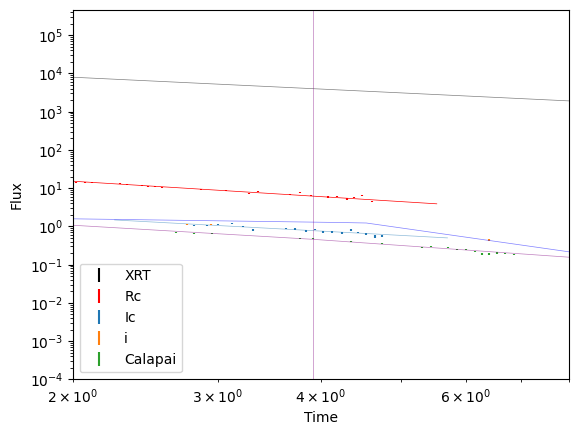

In [ ]:
alz_xrt.plot_data(scale=1e10, color="k", label="XRT")
alz_xrt.plot_model(color="k", scale=1e10, lw=0.5, alpha=0.5)
print("XRT", alz_xrt.best_fit_params)

alz_Rc.plot_data(scale=10, color="red", label="Rc")
alz_Rc.plot_model(color="red", scale=10, lw=0.5)
print("Rc", alz_Rc.best_fit_params)

# alz_r.plot_data(scale=10, color="brown", label="r and r'")
# alz_r.plot_model(color="brown", scale=10, lw=0.5)
# plt.axvline(alz_r.best_fit_params[1], color="brown", lw=0.5, alpha=0.5)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="C0", lw=0.5, alpha=0.5)
print("Ic", alz_Ic.best_fit_params)

alz_i.plot_data(label="i")
alz_i.plot_model(color="blue", lw=0.5, alpha=0.5)
#plt.axvline(alz_i.best_fit_params[3], color="blue", lw=0.5, alpha=0.5)
print("i", alz_i.best_fit_params)

alz_calapai.plot_data(label="Calapai")
alz_calapai.plot_model(color="purple", lw=0.5, alpha=0.5)
plt.axvline(alz_calapai.best_fit_params[1], color="purple", lw=0.5, alpha=0.5)
print("Calapai", alz_calapai.best_fit_params)
# alz_g.plot_data(label="g")
# alz_g.plot_model(color="green", lw=0.5, alpha=0.5)


plt.legend()

plt.ylim(1e-4,)

plt.xlim(2, 8)

In [ ]:
alz_i.print_posterior()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
print("XRT", alz_xrt.best_fit_params)
print("Rc", alz_Rc.best_fit_params)
print("r", alz_r.best_fit_params)
print("Ic", alz_Ic.best_fit_params)
print("i", alz_i.best_fit_params)
print("g", alz_g.best_fit_params)


XRT [1.5325032950404544e-11, 1.0292361934504495]
Rc [0.003811474638082948, 1.3357691628763726]
r [0.0011593132062532535, 2.4412438785450163, 1.1402459187995233, 1.6204672660992312]
Ic [0.0037680984270095437, 1.1628391170605388]
i [3.9455187529761485e-08, 3.3518121597601214, 0.0018330686386611782, 2.0028779701609687, 0.1918698900659035, 1.4866259171789453, 0.014432032371887834]
g [0.0034729198838764318, 1.529040299483159]
